# Bibliotecas e Funções

In [1]:
!pip install pennylane --upgrade
!pip install qutip.qip
!pip install qutip
!pip install qiskit
!pip install qiskit-aer
!pip install "qiskit-aer[qiskit-ibm-provider]"
!pip install -U
!pip install pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.8/930.8 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 32.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 26.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 13.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.8/140.8 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.1/30.1 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 39.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB

In [2]:
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from qutip import Qobj, tensor, identity, qeye, ket2dm,ptrace
import qutip as qt
import seaborn as sns
from scipy.linalg import expm, sinm, cosm
from qutip_qip.operations import *
from qutip import Qobj, sigmax, sigmay, sigmaz , tensor, qeye,ptrace
import matplotlib.pyplot as plt
import pennylane as qml
from tqdm import tqdm
import qiskit
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2,FakeAlgiers,FakeBelemV2
from qiskit_aer import noise
from qiskit_aer import AerSimulator

/usr/local/lib/python3.11/dist-packages/pennylane/capture/capture_operators.py:33: RuntimeWarning: PennyLane is not yet compatible with JAX versions > 0.4.28. You have version 0.5.2 installed. Please downgrade JAX to <=0.4.28 to avoid runtime errors.
  warnings.warn(


In [3]:
class QuantumCircuit:
    def __init__(self, num_qubits=2,eb=0.5,shot=1000,type_dev="default.mixed",backend_dev=None):
        #entrada de dados
        self.num_qubits = num_qubits
        self.shot=shot
        if shot==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits)
        if backend_dev==None:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot)
        else:
          self.dev = qml.device(type_dev, wires=self.num_qubits,shots=shot,backend=backend_dev)
        self._phi_inicial =qml.QNode(self.__phi_inicial,self.dev)
        self._phi_final =qml.QNode(self.__phi_final,self.dev)
        self._caixa_SWAP =qml.QNode(self.__caixa_SWAP,self.dev)
        self._phi_entagled =qml.QNode(self.__phi_entagled,self.dev)
        self.eb=eb

    def thetas_c(self,bb=2,ea=1,ba=1):
    #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x
    def u_minus1(self,x):
        # Calculate the components
        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 - term2
        return np.array((u_minus).full())

    def u_plus1(self,x):
        # Calculate the components

        term1 = 1 * np.sqrt(1 - x) * qeye(2)
        term2 = (1j * np.sqrt(x)) * qt.sigmay()
        u_minus = term1 + term2

        return np.array((u_minus).full())

    def __phi_entagled(self,theta_A,theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(i+1)], wires=[i])
          qml.CNOT(wires=[i,self.num_qubits-(i+1)])

        #conectar estados termalizados
        for i in range(1,int(self.num_qubits)-1):
          qml.CNOT(wires=[i,(i+1)])
          qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[(i+1)], wires=[i])
          qml.CNOT(wires=[i,(i+1)])

        return qml.state()

    def __phi_inicial(self,theta_A, theta_B,x=0.5):
        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)

        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa correlação
        for i in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        if self.shot==None:
          return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __phi_final(self,theta_A,theta_B,x=0.5):

        qml.RX(theta_A, wires=0)
        qml.RX(theta_B, wires=self.num_qubits-1)
        #caixa termalizado
        for i in range(1,int(self.num_qubits/2)):
          qml.CNOT(wires=[0, i])
          qml.CNOT(wires=[self.num_qubits-1,self.num_qubits-(i+1) ])

        #caixa de correlação
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_minus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])

        #caixa SWAP
        for i in range(1,int(self.num_qubits/2)):
          #for j in range(1,int(self.num_qubits/2)):
            j=i
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
            qml.ControlledQubitUnitary(self.u_plus1(x), control_wires=[self.num_qubits-(j+1)], wires=[i])
            qml.CNOT(wires=[i,self.num_qubits-(j+1)])
        if self.shot==0:
          return qml.state()
        if self.num_qubits==8:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3))*0.5-0.5*((qml.PauliZ(4)+qml.PauliZ(5)+qml.PauliZ(6))))
        elif self.num_qubits==10:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4))*0.5-0.5*((qml.PauliZ(5)+qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8))))
        elif self.num_qubits==12:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2)+qml.PauliZ(3)+qml.PauliZ(4)+qml.PauliZ(5))*0.5-0.5*((qml.PauliZ(6)+qml.PauliZ(7)+qml.PauliZ(8)+qml.PauliZ(9)+qml.PauliZ(10))))
        elif self.num_qubits==6:
          return qml.expval(-self.eb*(qml.PauliZ(1)+qml.PauliZ(2))*0.5-0.5*((qml.PauliZ(3)+qml.PauliZ(4))))
        elif self.num_qubits==4:
          return qml.expval(-self.eb*(qml.PauliZ(1))*0.5-0.5*((qml.PauliZ(2))))


    def __caixa_SWAP(self,x,rho):
      #gerando uma lista com os fios
      wires_list=[]
      for i in range(self.num_qubits):
        wires_list.append(i)

      qml.QubitDensityMatrix(rho, wires=wires_list)
      #caixa swap
      for i in range(self.num_qubits):
        qml.U3(x[i+0],x[i+1],x[i+2], wires=i)

      return qml.state()

    def hamiltoniana(self,eb,ea=1):
      #gerando a matriz identidade para gerar os circuitos
      resultfi=Qobj(np.zeros([2**(self.num_qubits-2),2**(self.num_qubits-2)]),dims=(cnot(self.num_qubits-2,0,1).dims))
      inteiro=int((self.num_qubits)/2)
      #gerando o hamiltoniano para Num Qubits

      for i in range(1,self.num_qubits-1):
        result=Qobj(1)
        for j in range(1,self.num_qubits-1):
          if i==j and i<inteiro:
            result=tensor(result,-ea*qt.sigmaz()/2)

          elif i==j and i>=inteiro:
            result=tensor(result,-eb*qt.sigmaz()/2)

          else:
            result=tensor(result,qeye(2))

        resultfi=resultfi+Qobj(result,dims=cnot(self.num_qubits-2,0,1).dims)

      return resultfi

    #compilador
    def compiled_ibm(self,circuit):#tem que alterar
        compiled_circuit = qml.compile(circuit, pipeline=[
                partial(qml.transforms.commute_controlled, direction="left"), # Now partial is defined
                partial(qml.transforms.merge_rotations, atol=1e-6), # Now partial is defined
                qml.transforms.cancel_inverses
            ],basis_set=["CNOT", "SX", "RZ"],num_passes=4)
        return compiled_circuit

    # Métodos para acessar os circuitos phi_inicial e phi_final
    def get_phi_inicial(self):
        return self.__phi_inicial

    def get_phi_final(self):
        return self.__phi_final
    #truque para gerar a biblioteca do penny lane com POO
    def phi_inicial(self,theta_A, theta_B,x=0.5):
      return self._phi_inicial(theta_A, theta_B,x)

    def phi_entagled(self,theta_A, theta_B,x=0.5):
      return self._phi_entagled(theta_A, theta_B,x)

    def draw(self,function):#resposta temporaria
      qml.draw_mpl(function)(1,1,0.5)
      return

    def caixa_SWAP(self,x,rho):
      return self._caixa_SWAP(x,rho)

    def phi_final(self,theta_A,theta_B,x=0.5):
      return self._phi_final(theta_A,theta_B,x)

class MyGates:
  def __init__(self,num_qubits=2):
    pass
class QuantumOptimization:
    dev=None
    def __init__(self,rho,num_qubits=2,epsilon=0.05,eb=0.5):
        self.num_qubits = num_qubits
        self.epsilon=epsilon
        self.eb=eb
        self.rho=rho
        self.trace=np.linspace(1,num_qubits-2,num_qubits-2,dtype=int)
        self.quantum_circuit = QuantumCircuit(self.num_qubits)
        #self.dev = qml.device("default.mixed", wires=self.num_qubits)
        #self.circuit = qml.QNode(self.__circuit, self.dev)

    def loss1(self, rho0, rhof, H):
        #função custo baseado no trabalho
        return np.real(((qt.ptrace(rhof,self.trace) - qt.ptrace(rho0,self.trace)) * H).tr())

    def thetas_c(self,bb=2,ea=1,ba=1):
      #parametro de correlação
      #parametros do sistema
      bb=bb*ba
      #hamiltoniana do sitema
      sz=np.array([[1, 0], [0, -1]])

      H_A=-0.5*ea*sz
      H_B=-0.5*self.eb*sz

      # Função partição
      Za = np.trace(expm(-ba * H_A))

      Zb = np.trace(expm(-bb * H_B))
      #operador densidade

      p_a=np.exp(-ba*ea/2)/Za
      p_b=np.exp(-bb*self.eb/2)/Zb
      #coeficiente

      a=1/(Za*Zb)

      pp=0.5*(p_a+p_b+np.sqrt((p_b-p_a)**2+4*a**2))

      pm=0.5*(p_a+p_b-np.sqrt((p_b-p_a)**2+4*a**2))

      x=((p_b-p_a)/(pp-pm)+1)*0.5
      #angulo para rotação x
      theta_a=2*np.arccos(np.sqrt(pp))
      theta_b=2*np.arccos(np.sqrt(pm))

      return theta_a,theta_b,x

    def loss_function(self, params):
        #estado inicial
        rho=self.rho

        rho0 =  qt.Qobj(rho, dims=cnot(self.num_qubits, 0, 1).dims)

        #estado final
        rhof = qt.Qobj(self.quantum_circuit.caixa_SWAP(params, rho), dims=cnot(self.num_qubits, 0, 1).dims)
        H = self.quantum_circuit.hamiltoniana(eb)

        return self.loss1(rho0, rhof, H)

    def parameter_shift_gradient(self, params, j):
        # metod do gradiente
        epsilon = self.epsilon
        shifted_params_plus = params.copy()
        shifted_params_plus[j] += epsilon

        shifted_params_minus = params.copy()
        shifted_params_minus[j] -= epsilon

        gradient = (
            self.loss_function(shifted_params_plus)
            - self.loss_function(shifted_params_minus)
        ) / (2 * epsilon)
        return gradient


    def stochastic_gradient_descent(self, params, learning_rate, num_epochs):
        epoch = 0
        loss = 0
        loss_vec = []
        epochs_vec = []
        #otimizando parametros
        for _ in range(num_epochs):
            #otimização
            for j in range(len(params)):
                gradient = self.parameter_shift_gradient(params, j)
                params[j] -= learning_rate * np.real(gradient)

            loss = self.loss_function(params)
            loss_vec.append(loss)
            epochs_vec.append(epoch)
            epoch += 1
        return params, loss_vec[-1]

class Plots:
  def __init__(self):
    pass
  def plotar(self,x,y,labelx=None,labely=None):
    plt.plot(x,y,'.')
    plt.ylabel(labely)
    plt.xlabel(labelx)
    plt.grid(True)
    plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
100%|██████████| 21/21 [00:15<00:00,  1.39it/s]


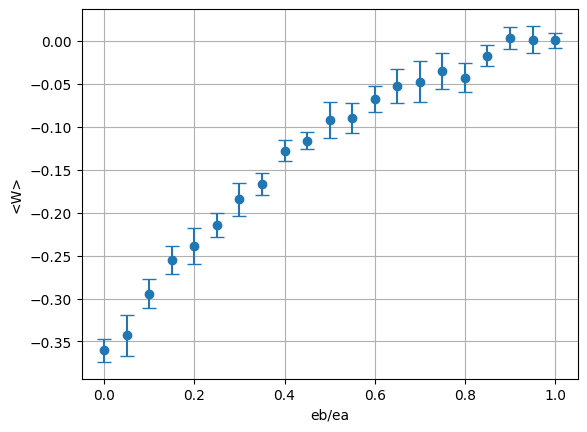

In [4]:
num_qubits=4
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1.5,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan6=QuantumCircuit(num_qubits,eb,1000)
  theta_a,theta_b,x=Quan6.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan6.phi_inicial(theta_a,theta_b,x)
    expval2=Quan6.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

100%|██████████| 21/21 [00:29<00:00,  1.42s/it]


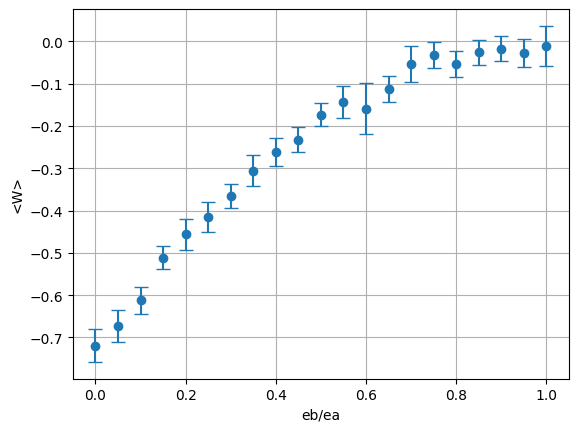

In [5]:
num_qubits=6
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan6=QuantumCircuit(num_qubits,eb,1000)
  theta_a,theta_b,x=Quan6.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan6.phi_inicial(theta_a,theta_b,x)
    expval2=Quan6.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

# Fake provider

## Exemplo

In [7]:
import pennylane as qml

import qiskit
from qiskit_ibm_runtime.fake_provider import FakeAlmadenV2,FakeAlgiers,FakeBelemV2
from qiskit_aer import noise
from qiskit_aer import AerSimulator


# Create a PennyLane device
dev = qml.device(
    'qiskit.aer',
    wires=2,
    backend=FakeBelemV2(),
    validation_threshold=1e-6
)

# Create a PennyLane quantum node run on the device
@qml.qnode(dev)
def circuit(x, y, z):
    qml.RZ(z, wires=[0])
    qml.RY(y, wires=[0])
    qml.RX(x, wires=[0])
    qml.CNOT(wires=[0, 1])
    return qml.expval(qml.PauliZ(wires=1))

# Result of noisy simulator
print(circuit(0.2, 0.1, 0.3))

0.953125


## Teste no Circuito da Irene


  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWa

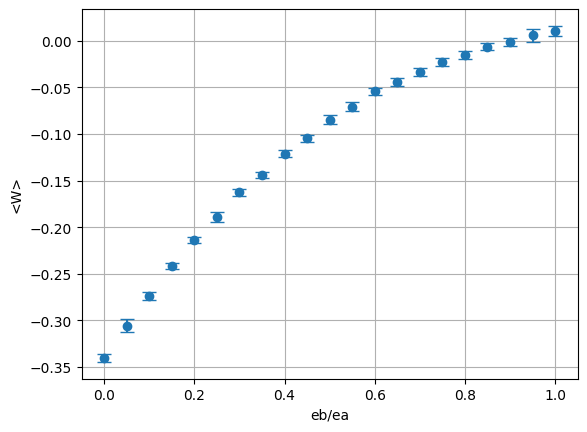

In [8]:
num_qubits=4
n=21
#gerando estado inicial
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan7=QuantumCircuit(num_qubits,eb,20000,"qiskit.aer",FakeAlgiers())#circuito Irene
  theta_a,theta_b,x=Quan7.thetas_c()#rotações
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)# estado inicial
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
#plotando
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWa

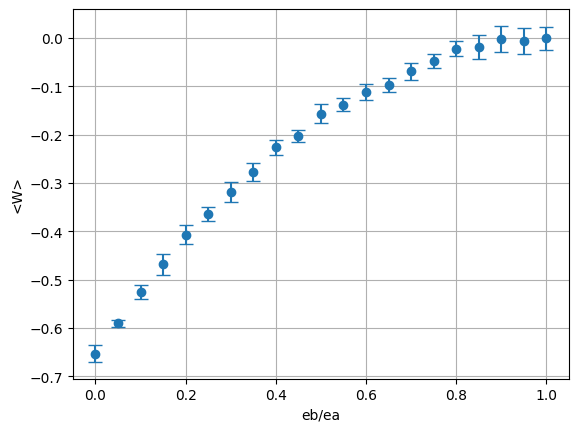

In [9]:
num_qubits=6
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan7=QuantumCircuit(num_qubits,eb,20000,"qiskit.aer",FakeAlgiers())
  theta_a,theta_b,x=Quan7.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWa

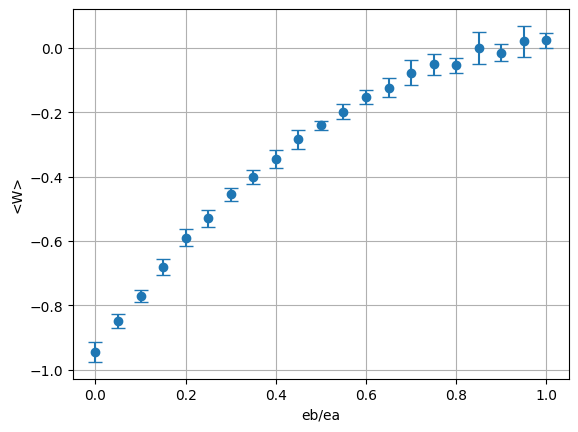

In [10]:
num_qubits=8
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan7=QuantumCircuit(num_qubits,eb,20000,"qiskit.aer",FakeAlgiers())
  theta_a,theta_b,x=Quan7.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWa

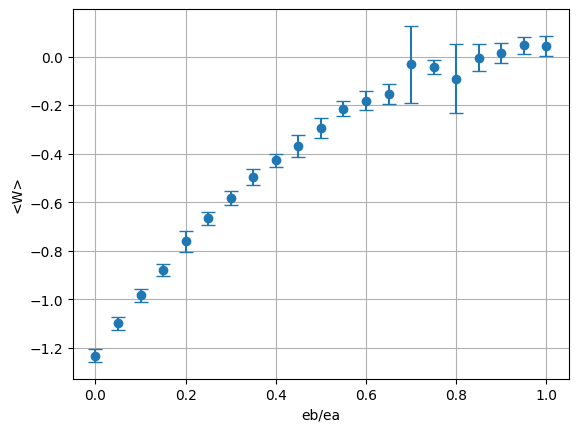

In [11]:
num_qubits=10
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan7=QuantumCircuit(num_qubits,eb,20000,"qiskit.aer",FakeAlgiers())
  theta_a,theta_b,x=Quan7.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

In [ ]:
num_qubits=12
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(tqdm(ebs)):
  Quan7=QuantumCircuit(num_qubits,eb,20000,"qiskit.aer",FakeAlgiers())
  theta_a,theta_b,x=Quan7.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

  0%|          | 0/21 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWarning: The control_wires input to ControlledQubitUnitary is deprecated and will be removed in v0.42. Please note that the second positional arg of your input is going to be the new wires, following wires=controlled_wires+target_wires, where target_wires is the optional arg wires in the legacy interface.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pennylane/ops/op_math/controlled_ops.py:41: PennyLaneDeprecationWa

In [ ]:
num_qubits=14
n=21
ebs=np.linspace(0,1,n)
expval_med=np.linspace(0,1,n)
expval_var=np.linspace(0,1,n)
expval1=np.linspace(0,1,n)
expval2=np.linspace(0,1,n)
sum=[]
plot=Plots()
for i,eb in enumerate(ebs):
  Quan7=QuantumCircuit(num_qubits,eb,20000)
  theta_a,theta_b,x=Quan7.thetas_c()
  for j in range(10):#fazendo média
    expval1=Quan7.phi_inicial(theta_a,theta_b,x)
    expval2=Quan7.phi_final(theta_a,theta_b,x)
    sum.append(-expval2+expval1)
  expval_med[i]=np.mean(sum)
  expval_var[i]=np.std(sum)
  sum=[]
plt.errorbar(ebs,expval_med,expval_var, fmt='o', capsize=5)
plt.ylabel('<W>')
plt.xlabel('eb/ea')
plt.grid(True)
plt.show()

# Transpilar/Decomposição

## Exemplo

In [ ]:
from functools import partial # Import the partial function from functools
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from pennylane.transforms import commute_controlled, merge_rotations, cancel_inverses

def circuit():
    qml.CNOT(wires=[0, 1])
    qml.PauliY(wires=0)
    qml.CNOT(wires=[2, 3])
    qml.Hadamard(wires=3)
    qml.CNOT(wires=[1, 2])
    qml.PauliZ(wires=0)
    qml.PauliX(wires=1)
    qml.Hadamard(wires=2)
    qml.CNOT(wires=[3,1])
    qml.PauliZ(wires=2)
    qml.CNOT(wires=[0, 3])
    return qml.probs(wires=[0, 1, 2, 3])

dev = qml.device('default.qubit', wires=4)
qnode = qml.QNode(circuit, dev)
print(qml.draw(qnode)())

compiled_circuit = qml.compile(circuit, pipeline=[
        partial(qml.transforms.commute_controlled, direction="left"), # Now partial is defined
        partial(qml.transforms.merge_rotations, atol=1e-6), # Now partial is defined
        qml.transforms.cancel_inverses
    ],basis_set=["CNOT", "RX", "SX", "RZ"],num_passes=2)
compiled_qnode = qml.QNode(compiled_circuit, dev)
print(qml.draw(compiled_qnode)())

## Circuito da Irene

In [ ]:
from functools import partial # Import the partial function from functools
import pennylane as qml
import numpy as np
import matplotlib.pyplot as plt
from pennylane.transforms import commute_controlled, merge_rotations, cancel_inverses
num_qubits=4
eb=0.1
dev = qml.device('default.qubit', wires=4)
Quan7=QuantumCircuit(num_qubits,eb,20000)
qc = QuantumCircuit(num_qubits=4)
theta_a,theta_b,x=Quan7.thetas_c()
# Acessando os métodos privados
phi_inicial = qc.get_phi_inicial()
phi_final = qc.get_phi_final()

qml.draw_mpl(phi_final, decimals=1, style="sketch")(theta_a,theta_b,x)
plt.show()

compiled_circuit = qml.compile(phi_final, pipeline=[
        partial(qml.transforms.commute_controlled, direction="left"), # Now partial is defined
        partial(qml.transforms.merge_rotations, atol=1e-7), # Now partial is defined
        qml.transforms.cancel_inverses
    ],basis_set=["CNOT","SX","RZ"]
      ,num_passes=8)
compiled_qnode = qml.QNode(compiled_circuit, dev)
qml.draw_mpl(compiled_qnode, decimals=1, style="sketch")(theta_a,theta_b,x)

In [ ]:
qc = QuantumCircuit(num_qubits=4)

# Acessando os métodos privados
phi_inicial = qc.get_phi_inicial()
phi_final = qc.get_phi_final()
style="sketch"

qml.draw_mpl(phi_final, decimals=1, style="sketch")(1,1,0.5)
plt.show()
# Compilando os circuitos
compiled_phi_inicial = qc.compiled_ibm(phi_inicial)
compiled_phi_final = qc.compiled_ibm(phi_final)

# Agora você pode usar compiled_phi_inicial e compiled_phi_final
# como circuitos compilados para as portas CNOT, SX e RZ.

In [ ]:
import pennylane as qml

dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def circuit():
    qml.SX(wires=0)
    return qml.expval(qml.PauliZ(0))

compiled_circuit = qml.compile(circuit, basis_set=["CNOT", "RX","RY", "RZ"])

print(qml.draw(circuit)())
print(qml.draw(compiled_circuit)())

## Decompondo a porta RX e RY

In [ ]:
import qiskit as qis
qc = qis.QuantumCircuit(2)
qc.h(0)
qc.cx(0,1)
qc = qis.transpile(qc, basis_gates=['cx', 'id', 'rz', 'x', 'sx'])
print(qc)

In [ ]:
qc1 = qis.QuantumCircuit(2)
#theta_a,theta_b,x=Quan7.thetas_c()
qc1.ry(0,0)
qc1.rx(0,1)
qc1 = qis.transpile(qc1, basis_gates=['cx', 'id', 'rz', 'x', 'sx'])
print(qc1)

In [ ]:
qc1 = qis.QuantumCircuit(1)
theta_a,theta_b,x=Quan7.thetas_c()
qc1.u(theta_a,theta_b,x,0)

qc1 = qis.transpile(qc1, basis_gates=['cx', 'id', 'rz', 'x', 'sx'])
print(qc1)

# Otimizado o $\alpha$

  0%|          | 0/101 [00:00<?, ?it/s]<ipython-input-4-353df9de70ad>:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ind[0]=alpha
<ipython-input-4-353df9de70ad>:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ind[1]=a+b-2*a*b-alpha
<ipython-input-4-353df9de70ad>:16: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ind[2]=0.5*(1-b+a*(2*b-1)-pmp)
<ipython-input-4-353df9de70ad>:17: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and

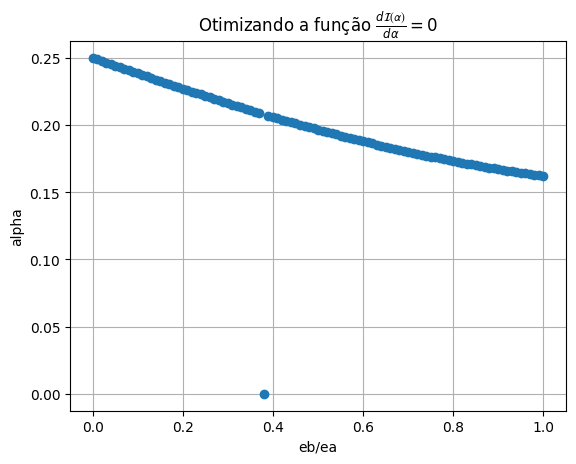

In [ ]:
from scipy.optimize import fsolve
def mutual_information(a,b,alpha):
  #rhoa=np.array(rhoa)
  #rhob=np.array(rhob)
  ind=np.zeros(4)
  ind[0]=alpha
  ind[1]=a+b-2*a*b-alpha
  pmp=np.sqrt(
    (
        (-1 + a)**2 * (a - 2*alpha)**2
        - 2*(-1 + a)*(-1 + 2*a)*(a*(-5 + 2*a) + 2*alpha - 6*a*alpha + 4*alpha**2)*b
        + (-1 + 2*a)*(-1 + 12*a**3 - 4*alpha*(2 + alpha) - 6*a**2*(7 + 4*alpha) + 4*a*(8 + alpha*(7 + 2*alpha)))*b**2
        - 2*(-1 + 2*a)*(-1 - 2*alpha + 2*a*(7 + 2*a*(-5 + 2*a - 2*alpha) + 4*alpha))*b**3
        + (1 - 2*a)**4 * b**4
    ) / (a + b - 2*a*b)**2)
  ind[2]=0.5*(1-b+a*(2*b-1)-pmp)
  ind[3]=0.5*(1-b+a*(2*b-1)+pmp)
  entropy=0.0
  entropy-=a*np.log(a)
  entropy-=b*np.log(b)
  if a<1:
    entropy-=(1-a)*np.log(1-a)

  if b<1:
    entropy-=(1-b)*np.log(1-b)
  for i in range(4):
    if ind[i]>0:
      entropy-=ind[i]*np.log(ind[i])
  return entropy
def rho2(a):
  return np.array([[a,0],[0,1-a]])
def rho4(a,b,alpha):
  ind00=alpha
  ind11=a+b-2*a*b-alpha
  pmp=np.sqrt(
    (
        (-1 + a)**2 * (a - 2*alpha)**2
        - 2*(-1 + a)*(-1 + 2*a)*(a*(-5 + 2*a) + 2*alpha - 6*a*alpha + 4*alpha**2)*b
        + (-1 + 2*a)*(-1 + 12*a**3 - 4*alpha*(2 + alpha) - 6*a**2*(7 + 4*alpha) + 4*a*(8 + alpha*(7 + 2*alpha)))*b**2
        - 2*(-1 + 2*a)*(-1 - 2*alpha + 2*a*(7 + 2*a*(-5 + 2*a - 2*alpha) + 4*alpha))*b**3
        + (1 - 2*a)**4 * b**4
    ) / (a + b - 2*a*b)**2)
  ind22=0.5*(1-b+a*(2*b-1)-pmp)
  ind33=0.5*(1-b+a*(2*b-1)+pmp)
  print([[ind00,0,0,0],[0,ind11,0,0,0],[0,0,ind22,0],[0,0,0,ind33]])
  return [[ind00,0,0,0],[0,ind11,0,0,0],[0,0,ind22,0],[0,0,0,ind33]]

def f(alpha,a,b):
  epsilon=0.0001
  return (mutual_information(a,b,epsilon+alpha)-mutual_information(a,b,alpha))/epsilon
eb=np.linspace(0,1,101)
bb=2
ba=1
ea=1
vec=[]
for i in tqdm(range(len(eb))):
  za=np.exp(-ba*ea/2)+np.exp(ba*ea/2)
  zb=np.exp(-bb*eb[i]/2)+np.exp(bb*eb[i]/2)
  pa=np.exp(-ba*ea/2)/za
  pb=np.exp(-bb*eb[i]/2)/zb
  vec.append(fsolve(f,1,args=(pa,pb)))

plt.plot(eb,vec,'o')
plt.title("Otimizando a função $\\frac{d \\mathcal{I(\\alpha)}}{d \\alpha}=0$")
plt.xlabel("eb/ea")
plt.ylabel("alpha")
plt.grid(True)
plt.show()

## Circuito do estado X

In [ ]:
import math

def calcular_equacao(a, b, alpha1):
  """
  Calcula o resultado da equação:

  1/2 (1 + 1/(a + b - 2 a b)^2 (sqrt(1/(1 - b + a (-1 + 2 b))^2 (a + b - 2 a b)^2
  ((-1 + a)^2 (a - 2 alpha1)^2 - 2 (-1 + a) (-1 + 2 a) (a (-3 + 2 a) + 2 alpha1 - 6 a alpha1 + 4 alpha1^2) b
  + (-1 + 2 a) (-1 + 12 a^3 - 4 alpha1 (2 + alpha1) + 4 a (1 + alpha1) (5 + 2 alpha1) - 6 a^2 (5 + 4 alpha1)) b^2
  - 2 (-1 + 2 a) (-1 - 2 alpha1 + 2 a (5 + 4 a (-2 + a - alpha1) + 4 alpha1)) b^3 + (1 - 2 a)^4 b^4))))

  Args:
    a: Valor do parâmetro 'a'.
    b: Valor do parâmetro 'b'.
    alpha1: Valor do parâmetro 'alpha1'.

  Returns:
    O resultado da equação.
  """
  try:
    resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +
    (-1 + 2 * a) * (-1 + 12 * a**3 - 4 * alpha1 * (2 + alpha1) + 4 * a * (1 + alpha1) * (5 + 2 * alpha1) - 6 * a**2 * (5 + 4 * alpha1)) * b**2 -
    2 * (-1 + 2 * a) * (-1 - 2 * alpha1 + 2 * a * (5 + 4 * a * (-2 + a - alpha1) + 4 * alpha1)) * b**3 + (1 - 2 * a)**4 * b**4))))
    return resultado
  except:
    print("Erro ao calcular a equação. Verifique os valores de entrada.")
    return None

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


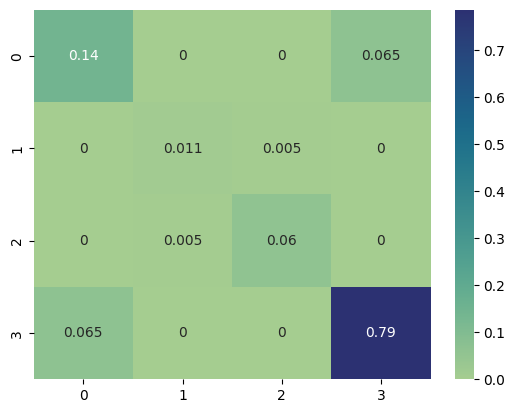

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


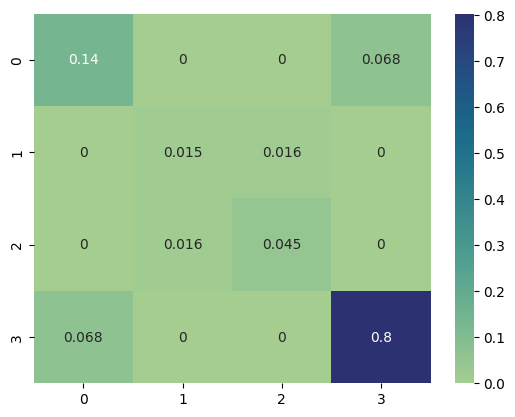

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


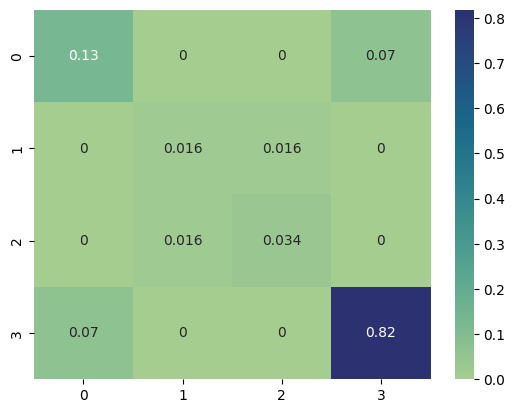

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


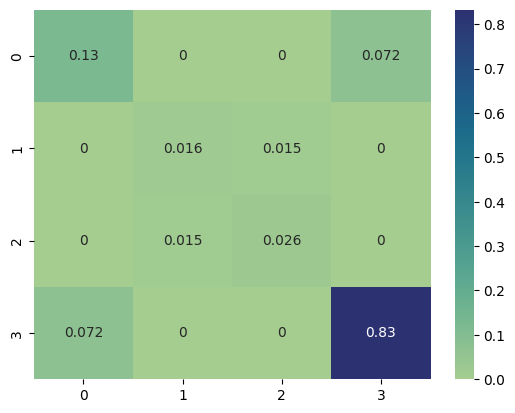

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


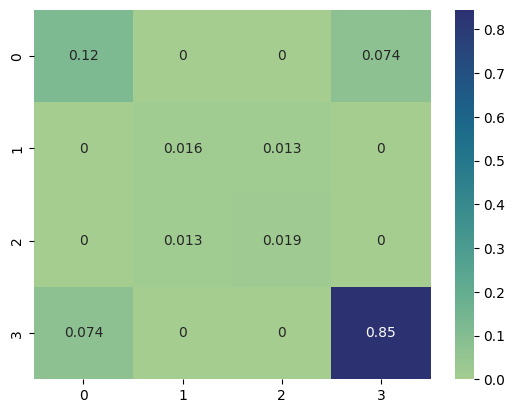

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


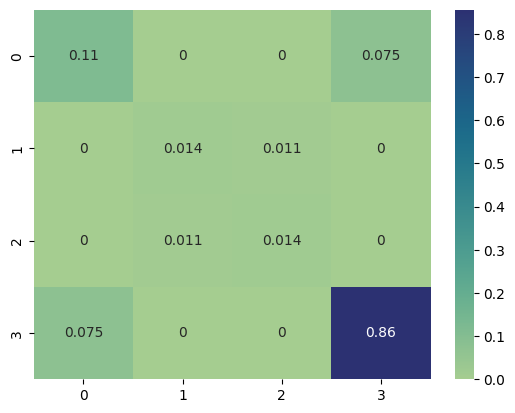

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


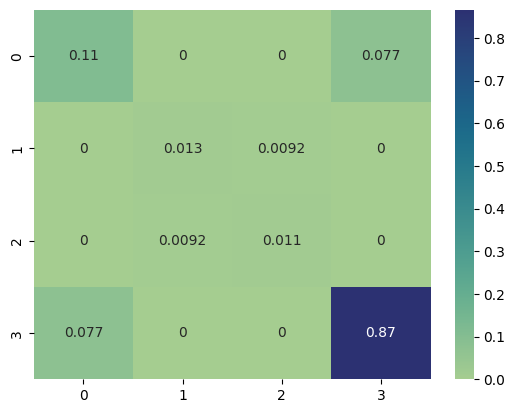

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


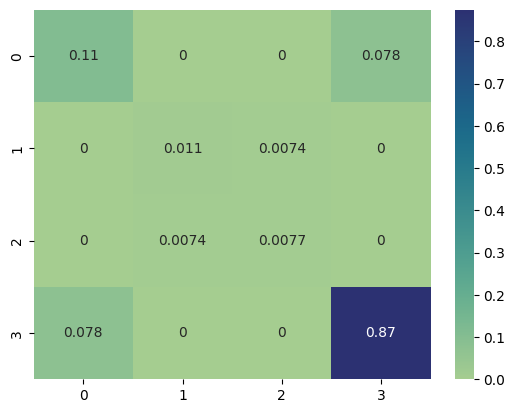

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


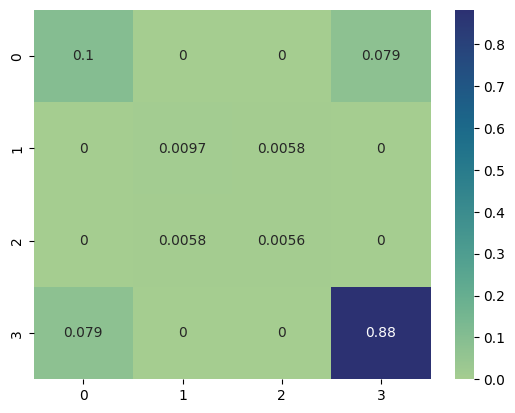

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


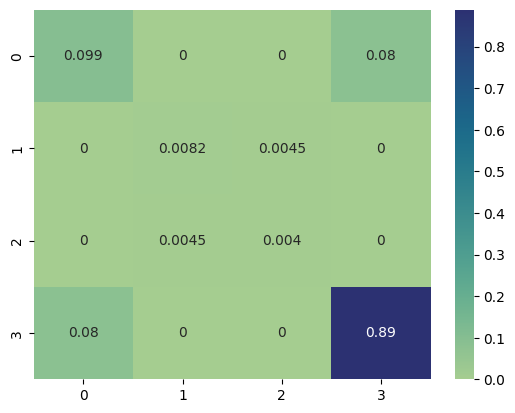

<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +


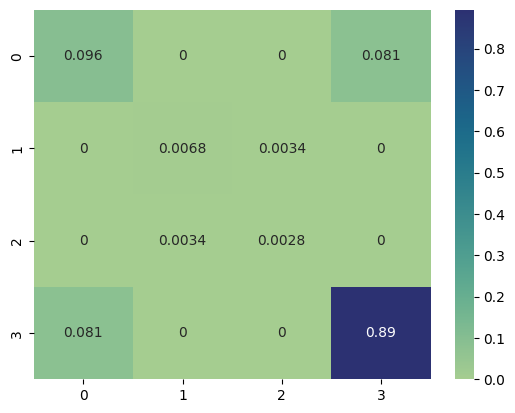

In [ ]:
def X_states(a,b,alpha):
  #coeficientes
  pp=calcular_equacao(a,b,alpha)
  x=1/2*(1-(b-a)/((2*pp-1)*(a+b-2*a*b)))
  y=1/2*(1-(1-b-a)/((2*pp-1)*(a+b-1-2*a*b)))
  pm=a*(2*b-1)-b+1
  #angulos
  theta=np.arcsin(np.sqrt(y))
  phi=np.arcsin(np.sqrt(x))
  phia=np.arccos(np.sqrt(pm))
  phib=np.arccos(np.sqrt(pp))
  return theta,phi,phia,phib

dev = qml.device("default.mixed", wires=4)
@qml.qnode(dev)
def circ_X_state(theta,phi,phia,phib):
  qml.RX(phia, wires=0)
  qml.RX(phib, wires=3)

  #caixa de termalização
  qml.CNOT(wires=[0,1])
  qml.CNOT(wires=[3,2])

  #gerar o estado X
  qml.RY(theta+phi, wires=1)
  qml.CNOT(wires=[2,1])
  qml.RY(theta-phi, wires=1)
  qml.CNOT(wires=[1,2])
  return qml.state()

def fy(alpha,a,b):
  pp=calcular_equacao(a,b,alpha)
  return 1/2*(1-(1-b-a)/((2*pp-1)*(a+b-1-2*a*b)))-0.99

vec=[]
#metricas
ba=1
bb=2
ea=1
eb=np.linspace(0,1,11)
for i in range(len(eb)):
  #valores de a e b
  za=np.exp(-ba*ea/2)+np.exp(ba*ea/2)
  zb=np.exp(-bb*eb[i]/2)+np.exp(bb*eb[i]/2)
  pa=np.exp(-ba*ea/2)/za
  pb=np.exp(-bb*eb[i]/2)/zb
  #alpha=fsolve(fy,1,args=(pa,pb))
  theta,phi,phia,phib=X_states(pa,pb,fsolve(fy,1,(pa,pb)))
  #plot do gráfico
  vec=qt.ptrace(qt.Qobj(circ_X_state(theta,phi,phia,phib), dims=cnot(4, 0, 1).dims),[1,2])
  sns.heatmap(np.real(vec.full()),annot=True,cmap="crest")
  #plt.title("estado X no valor $\\frac{eb}{ea}$="+str(round(eb[i],2)))
  plt.show()

#Testar a eficiência

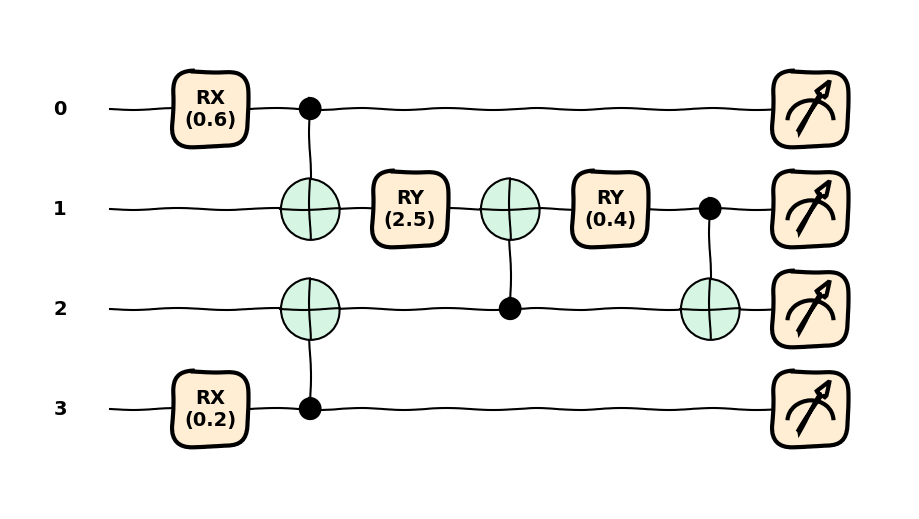

In [ ]:
qml.draw_mpl(circ_X_state, decimals=1, style="sketch")(theta,phi,phia,phib)
plt.show()

0it [00:00, ?it/s]<ipython-input-5-23c7ae01c2af>:21: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  resultado = 0.5 * (1 + (1 / (a + b - 2 * a * b)**2) * (math.sqrt((1 / (1 - b + a * (-1 + 2 * b))**2) * (a + b - 2 * a * b)**2 *((-1 + a)**2 * (a - 2 * alpha1)**2 - 2 * (-1 + a) * (-1 + 2 * a) * (a * (-3 + 2 * a) + 2 * alpha1 - 6 * a * alpha1 + 4 * alpha1**2) * b +
21it [04:50, 13.86s/it]


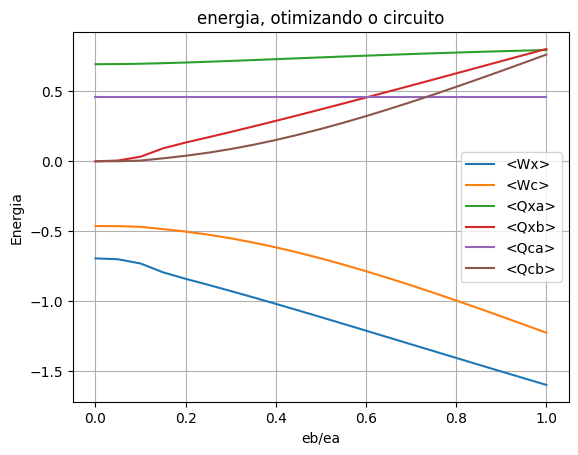

In [ ]:
# Exemplo de uso
params = np.random.rand(6)  # Inicialize os parâmetros aleatoriamente
learning_rate = 0.5
num_epochs = 50
ener=np.linspace(0,1,21)

ba=1
bb=2
ea=1

optimized_params=np.zeros(len(ener))
loss_vec1=np.zeros(len(ener))
loss_vec2=np.zeros(len(ener))
Qxa=np.zeros(len(ener))
Qxb=np.zeros(len(ener))
Qca=np.zeros(len(ener))
Qcb=np.zeros(len(ener))
for i,eb in tqdm(enumerate(ener)):
  za=np.exp(-ba*ea/2)+np.exp(ba*ea/2)
  zb=np.exp(-bb*eb/2)+np.exp(bb*eb/2)
  pa=np.exp(-ba*ea/2)/za
  pb=np.exp(-bb*eb/2)/zb
  Quan=QuantumCircuit(num_qubits=4,eb=eb,shot=None)
  Ha=qt.Qobj([[-ea/2,0],[0,ea/2]],dims=[[2],[2]])
  Hb=qt.Qobj([[-eb/2,0],[0,eb/2]],dims=[[2],[2]])

  #estado X
  theta,phi,phia,phib=X_states(pa,pb,fsolve(fy,1,(pa,pb)))
  rho0=circ_X_state(theta,phi,phia,phib)#variavel auxiliar
  aprendizado1=QuantumOptimization(rho=rho0,num_qubits=4)
  params,loss_vec1[i] = aprendizado1.stochastic_gradient_descent(params, learning_rate,num_epochs)

  #calor do estado X
  rho0x=qt.Qobj(rho0,dims=cnot(4,0,1).dims)
  rhofx=qt.Qobj(Quan.caixa_SWAP(params,rho0),dims=cnot(4,0,1).dims)
  Qxa[i]=np.real(((qt.ptrace(rho0x,1)-qt.ptrace(rhofx,1))*Ha).tr())
  Qxb[i]=np.real(((qt.ptrace(rho0x,2)-qt.ptrace(rhofx,2))*Hb).tr())

  #estado correlacionado
  theta_a,theta_b,x=Quan.thetas_c()
  rho0=Quan.phi_inicial(theta_a,theta_b,x)
  aprendizado2=QuantumOptimization(rho=rho0,num_qubits=4)

  #calor do estado correlacionado
  rho0c=qt.Qobj(rho0,dims=cnot(4,0,1).dims)
  rhofc=qt.Qobj(Quan.caixa_SWAP(params,rho0),dims=cnot(4,0,1).dims)
  Qca[i]=np.real(((qt.ptrace(rho0c,1)-qt.ptrace(rhofc,1))*Ha).tr())
  Qcb[i]=np.real(((qt.ptrace(rho0c,2)-qt.ptrace(rhofc,2))*Hb).tr())
  params,loss_vec2[i] = aprendizado2.stochastic_gradient_descent(params, learning_rate,num_epochs)

#plot do trabalho
plt.plot(ener,loss_vec1,label="<Wx>")
plt.plot(ener,loss_vec2,label="<Wc>")
#calores
plt.plot(ener,Qxa,label="<Qxa>")
plt.plot(ener,Qxb,label="<Qxb>")
plt.plot(ener,Qca,label="<Qca>")
plt.plot(ener,Qcb,label="<Qcb>")
#configurações
plt.xlabel('eb/ea')
plt.ylabel('Energia')
plt.title('energia, otimizando o circuito')
plt.legend()
plt.grid(True)
plt.show()

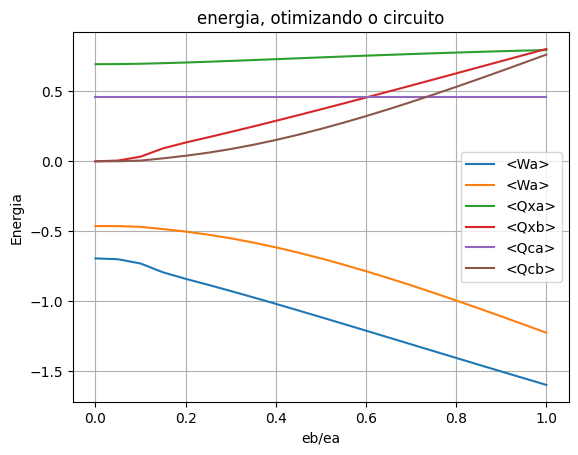

In [ ]:
#plot
plt.plot(ener,loss_vec1,label="<Wa>")
plt.plot(ener,loss_vec2,label="<Wa>")
plt.plot(ener,Qxa,label="<Qxa>")
plt.plot(ener,Qxb,label="<Qxb>")
plt.plot(ener,Qca,label="<Qca>")
plt.plot(ener,Qcb,label="<Qcb>")
plt.xlabel('eb/ea')
plt.ylabel('Energia')
plt.title('energia, otimizando o circuito')
plt.legend()
plt.grid(True)
plt.show()

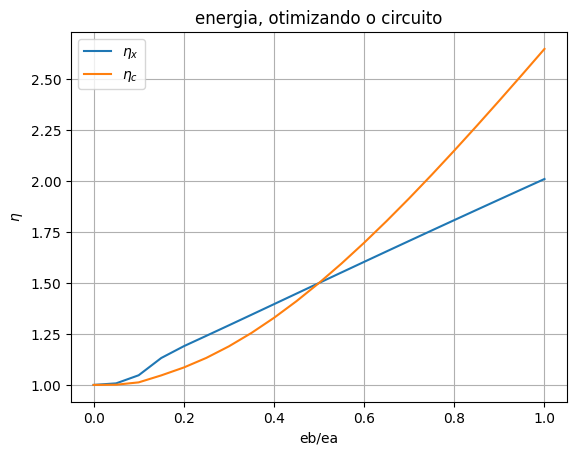

In [ ]:
plt.plot(ener,-loss_vec1/Qxa,label="$\\eta_{x}$")
plt.plot(ener,-loss_vec2/Qca,label="$\\eta_{c}$")
plt.xlabel('eb/ea')
plt.ylabel('$\\eta$')
plt.legend()
plt.title('energia, otimizando o circuito')
plt.grid(True)
plt.show()